PROYECTO PARA EL MÓDULO DE MACHINE LEARNING. EN ESTE PROYECTO, TENEMOS QUE CREAR UN MODELO QUE NOS PERMITA AVERIGUAR QUÉ CLIENTE TIENE ALTA PROBABILIDAD DE CANCELAR.

In [1]:
#instalar dependencias necesarias
# pip install pandas scikit-learn xgboost lightgbm optuna dalex imbalanced-learn matplotlib seaborn

In [33]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier


In [3]:
#importar fichero csv

df=pd.read_csv('../data/raw/reservas_hoteleras.csv')

In [4]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


PENALIZACIÓN POR UTILIZAR VARIABLES QUE PROPICIEN DATA LEAKAGE: reservation_status,reservation_status_date,assigned_room_type, booking_changes.
¿hacer algo con las fechas? ¿unirlas?

In [5]:
#nombre de todas las columnas para conocer mejor el dataset
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

¿relación entre días en lista de espera y cancelación?
¿los guests que repiten, han cancelado en algún momento? (teoría del buen guest)
hipótesis: un guest que ha cancelado una vez, lo hará más veces
tipos de hoteles que reciben más cancelaciones.
qué segmento del mercado cancela más

CONOCEMOS UN POQUITO EL DATASET, VIENDO LOS NULOS Y LOS DUPLICADOS

In [6]:
#valores nulos. Es importante saber qué tipo de dato es para hacernos una idea de cómo lo trataremos más adelante 
def resumen_variables(df):
    resumen = pd.DataFrame({
        "dtype": df.dtypes,
        "nulos": df.isnull().sum(),
        "pct_nulos": df.isnull().mean() * 100,
        "n_unique": df.nunique()
    })
    return resumen[resumen["nulos"] > 0]
resumen_variables(df)

,dtype,nulos,pct_nulos,n_unique
children,float64,4,0.003350,5
country,object,488,0.408744,177
agent,float64,16340,13.686238,333
company,float64,112593,94.306893,352


In [7]:
#valores duplicados
duplicados=df.duplicated().sum()
print(f'Valores duplicados: {duplicados} ({(duplicados/len(df))*100:.2f}%)') 

Valores duplicados: 31994 (26.80%)


3.1 EDA y comprensión del negocio
− Distribución de cancelaciones por hotel, mes y canal de distribución
− Relación entre lead_time y tasa de cancelación
− Comparación de ADR medio entre reservas canceladas y no canceladas
− Al menos una conclusión accionable por sección del EDA

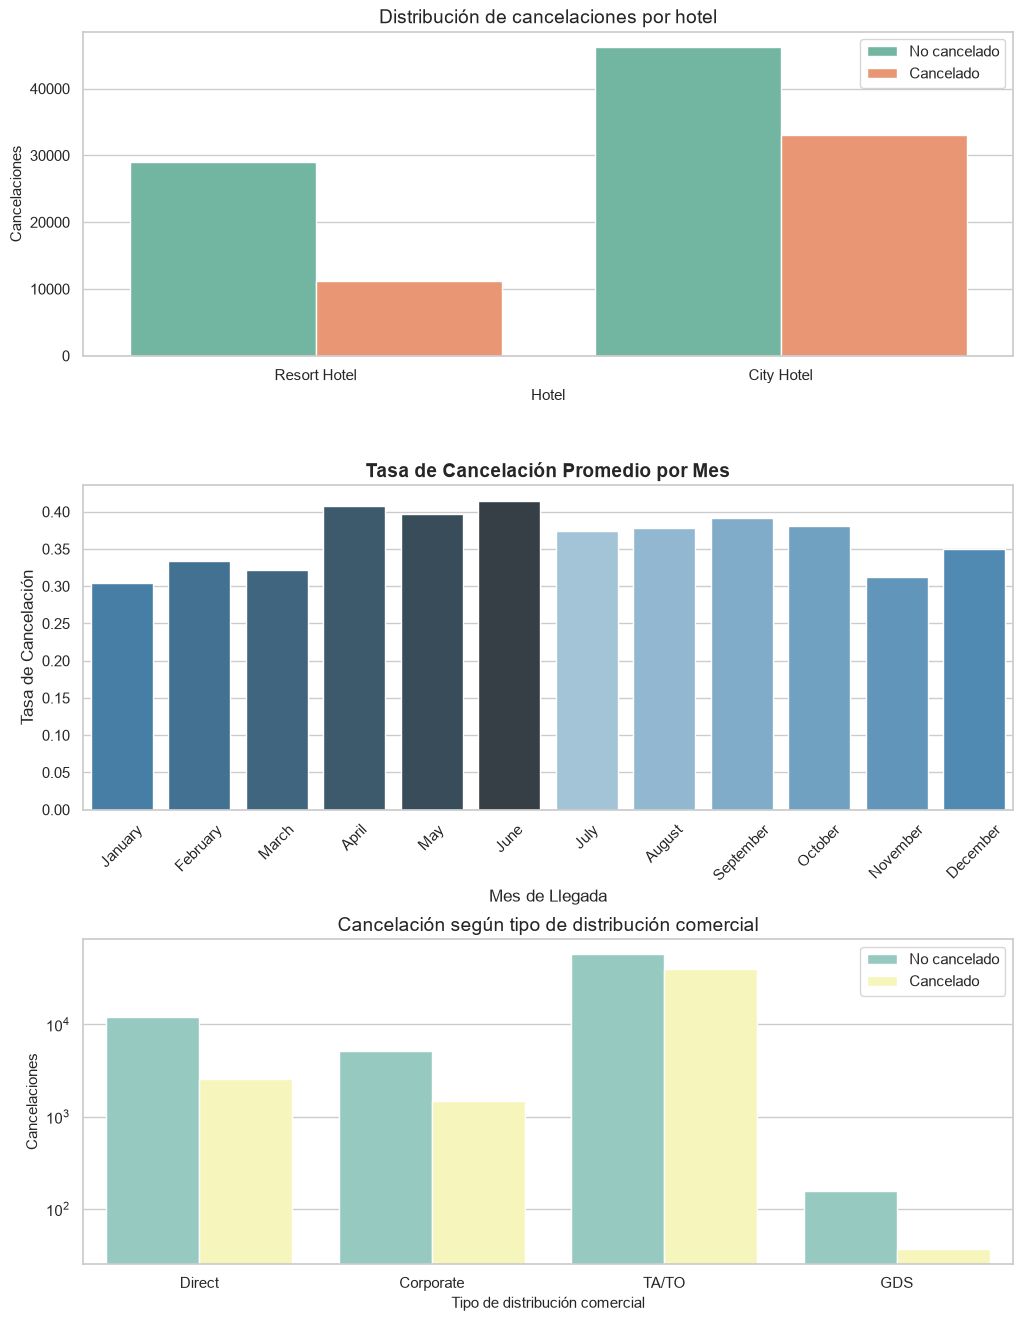

In [8]:
#Distribuciones de cancelaciones por hotel, mes y canal de distribución

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

fig, axes = plt.subplots(3, 1, figsize=(12, 16))
plt.subplots_adjust(hspace=0.4)

#Tipo de hotel. Qué tipo de hotel recibe más cancelaciones

sns.countplot(data=df, x='hotel', hue='is_canceled', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Hotel', fontsize=11)
axes[0].set_ylabel('Cancelaciones', fontsize=11)
axes[0].set_title('Distribución de cancelaciones por hotel', fontsize=14)
axes[0].legend(['No cancelado', 'Cancelado'])

#por mes. Qué meses reciben más cancelaciones.

ordenar_meses=['January', 'February', 'March', 'April', 'May', 'June', 
                 'July', 'August', 'September', 'October', 'November', 'December']

sns.barplot(data=df, x='arrival_date_month', y='is_canceled', hue='arrival_date_month', 
            legend=False, order=ordenar_meses, ax=axes[1], errorbar=None, palette='Blues_d')
axes[1].set_title('Tasa de Cancelación Promedio por Mes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes de Llegada')
axes[1].set_ylabel('Tasa de Cancelación')
axes[1].tick_params(axis='x', rotation=45)

#por canal de distribución. Travel Agents, tour operators, Direct, Corporate y GDS son las distribuciones comerciales más importantes.
#Eliminamos Undefined porque son apenas 5 registros y no tienen valor de negocio

df_filtrado=df[df['distribution_channel']!='Undefined']

#además, como la cantidad de reservas hechas por GDS es muy pequeña, no se apreciaría en pantalla, así que tenemos que 
#escalar el eje y.

sns.countplot(data=df_filtrado, x='distribution_channel', hue='is_canceled', ax=axes[2], palette='Set3')
axes[2].set_yscale('log')
axes[2].set_title('Cancelación según tipo de distribución comercial', fontsize=14)
axes[2].set_xlabel('Tipo de distribución comercial', fontsize=11)
axes[2].set_ylabel('Cancelaciones', fontsize=11)
axes[2].legend(['No cancelado', 'Cancelado'])

Text(0, 0.5, 'Tiempo previo a la entrada')

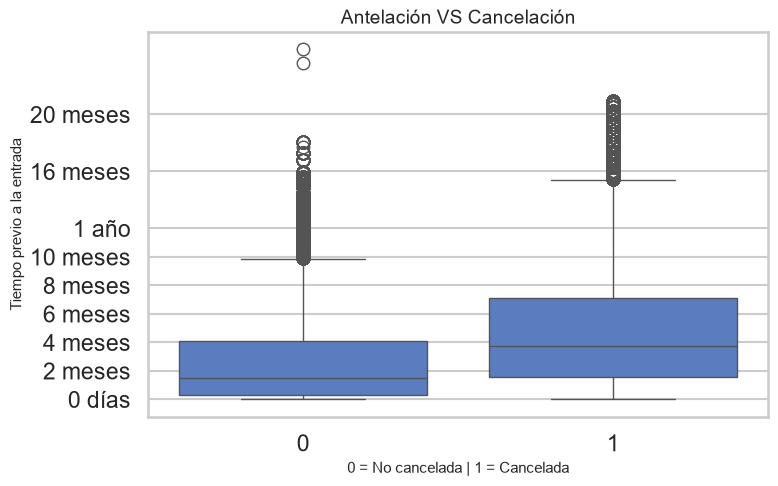

In [9]:
#relación entre lead_time (tiempo de espera entre que realizas la reserva y llegas el primer día al hotel) y tasa de cancelación

posiciones_dias = [0, 60, 120, 180, 240, 300, 360, 480, 600]
etiquetas_meses = ['0 días', '2 meses', '4 meses', '6 meses', '8 meses', '10 meses', '1 año', '16 meses', '20 meses']

sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)
plt.yticks(ticks=posiciones_dias, labels=etiquetas_meses)

sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title('Antelación VS Cancelación', fontsize=14)
plt.xlabel('0 = No cancelada | 1 = Cancelada', fontsize=11)
plt.ylabel('Tiempo previo a la entrada', fontsize=11)

Text(0.5, 1.0, 'Comparación entre ADR de reservas canceladas y no canceladas')

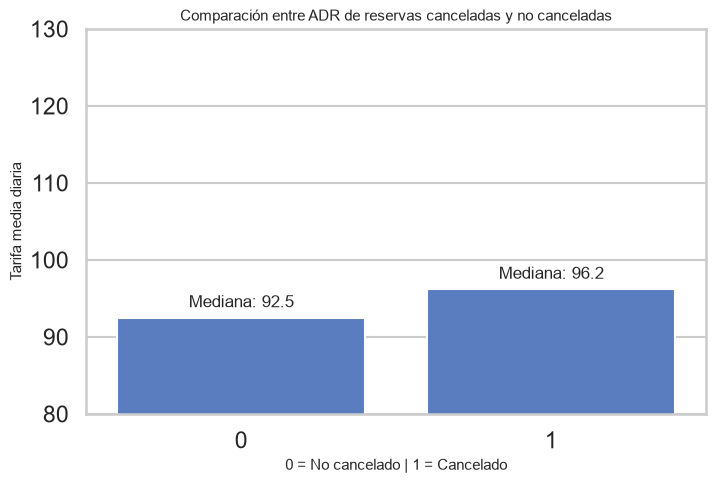

In [10]:
#comparación ADR (Average Daily Rate) medio de reservas canceladas y no canceladas

#calculamos el ADR. Primero agrupamos y luego hacemos la mediana (no usamos la media para evitar outliners) 
adr_mediana= df.groupby('is_canceled')['adr'].agg('median')
#print(adr_mediana)

ax=sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

plt.ylim(80,130)

ax=sns.barplot(x=adr_mediana.index, y=adr_mediana)

for p in ax.patches:
    ax.annotate(
        f'Mediana: {p.get_height():.1f}',
        (p.get_x()+p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,5),
        textcoords='offset points',
        fontsize=12
    )

plt.xlabel('0 = No cancelado | 1 = Cancelado', fontsize=11)
plt.ylabel('Tarifa media diaria', fontsize=11)
plt.title('Comparación entre ADR de reservas canceladas y no canceladas', fontsize=11)


(0.0, 0.45936897008565497)

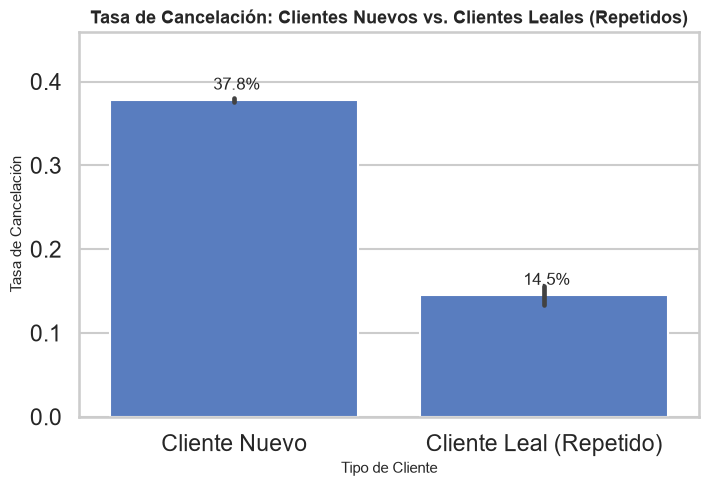

In [11]:
#ahora queremos saber si un cliente leal podría cancelar en algún momento

ax=sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)   

ax=sns.barplot(data=df, x='is_repeated_guest', y='is_canceled', estimator='mean')
for p in ax.patches:
    porcentaje=p.get_height()*100
    ax.annotate(
        f'{porcentaje: .1f}%',
        (p.get_x()+p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,5),
        textcoords='offset points',
        fontsize=12
    )

plt.title('Tasa de Cancelación: Clientes Nuevos vs. Clientes Leales (Repetidos)', fontsize=13, fontweight='bold')
plt.xlabel('Tipo de Cliente', fontsize=11)
plt.ylabel('Tasa de Cancelación', fontsize=11)
plt.xticks([0, 1], ['Cliente Nuevo', 'Cliente Leal (Repetido)'])
plt.ylim(0, ax.get_ylim()[1] * 1.15)

(0.0, 0.5)

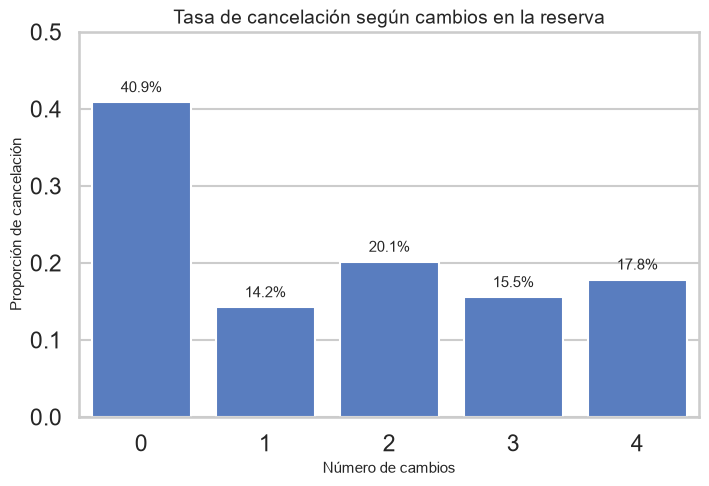

In [12]:
#el siguiente gráfico muestra si el haber cambios en la reserva condiciona la cancelación

sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

ax=sns.barplot(data=df[df['booking_changes']<5], x='booking_changes', y='is_canceled', estimator='mean', errorbar=None)


for p in ax.patches:
    porcentaje = p.get_height() * 100
    ax.annotate(
        f'{porcentaje:.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11
    )


plt.title('Tasa de cancelación según cambios en la reserva', fontsize=14)
plt.xlabel('Número de cambios', fontsize=11)
plt.ylabel('Proporción de cancelación', fontsize=11)
plt.ylim(0, 0.5)

In [13]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

FEATURE ENGINEERING: el objetivo es transformar y combinar variables crudas para que los modelos predictivos puedan capturar patrones más complejos.

Creación de variables que puedan resultar interesantes:
-Coste total de la estancia: totalnoches*adr
-total_guests (la del pdf): adults+children+babies
-duración total de la estancia: stays_in_weekend_nights+stays_in_week_nights
-cambiar booking_changes a binaria
-cambiar total_of_special_requests a binaria (esta variable es importante)




In [14]:
#duración total de la estancia
df['complete_stay']=df['stays_in_weekend_nights']+df['stays_in_week_nights']

In [15]:
#coste total de la estancia
df['total_cost']=df['complete_stay']*df['adr']

In [16]:
#total de huéspedes 
df['total_guests']=df['adults']+df['children']+df['babies']

In [17]:
#pasamos booking_changes a binario
df['has_changes']=(df['booking_changes']>0).astype(int)

In [18]:
#pasamos total_of_special_requests a binario
df['has_requests']=(df['total_of_special_requests']>0).astype(int)

In [19]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'complete_stay',
       'total_cost', 'total_guests', 'has_changes', 'has_requests'],
      dtype='object')

Una vez que hemos creado las variables que utilizaremos para entrenar el modelo, seguimos con el encoding.


In [20]:
#ONE-HOT ENCODING

#eliminamos las variables "chivatas"
if 'reservation_status' in df.columns:
    df = df.drop(columns=['reservation_status'])
if 'reservation_status_date' in df.columns:
    df = df.drop(columns=['reservation_status_date'])

#como country tiene una alta cardinalidad (más de 170 países), vamos a agruparlo  
#para ello, nos quedamos con el top 10 países que más reservas hacen

if 'country' in df.columns:
    top_10=df['country'].value_counts().head(10).index #obtenemos el valor de los 10 países con más reservas
    df['country_group']=df['country'].apply(lambda x: x if x in top_10 else 'other') #revisamos fila por fila el nombre de los países,
    #si está dentro de la lista, se deja tal cual, si no, se cambia a 'other'

    df=df.drop(columns=['country']) #eliminamos la columna country y dejamos country_group

# seleccionamos solo las columnas de texto/objeto
cols_text = df.select_dtypes(include=['object', 'category']).columns

# vemos cuántos valores únicos tiene cada una
categorical_cols=[col for col in cols_text if df[col].nunique() <= 12]

df_encoded=pd.get_dummies(df,columns=categorical_cols, drop_first=True, dtype=int)

#df_encoded.head(5)
    

In [21]:
#eliminamos las columnas que no son relevantes para nuestra predicción (arrival_date_year...)
delete_columns =[
    'arrival_date_year', #no interesa el histórico
    'arrival_date_day_of_month' #nos da igual el día exacto
    'stays_in_weekend_nights', #ya tenemos complete_stays
    'stays_in_week_nights', #mismo motivo
]

#eliminamos las columnas que empiezan con assigned_room_type porque es lo mismo que reserved_room_type
cols_assigned = [col for col in df_encoded.columns if col.startswith('assigned_room_type_')]
cols_delete = [c for c in (delete_columns + cols_assigned) if c in df_encoded.columns]

df_final = df_encoded.drop(columns=cols_delete)

In [22]:
df_final.columns

Index(['is_canceled', 'lead_time', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights', 'adults',
       'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'complete_stay', 'total_cost',
       'total_guests', 'has_changes', 'has_requests', 'hotel_Resort Hotel',
       'arrival_date_month_August', 'arrival_date_month_December',
       'arrival_date_month_February', 'arrival_date_month_January',
       'arrival_date_month_July', 'arrival_date_month_June',
       'arrival_date_month_March', 'arrival_date_month_May',
       'arrival_date_month_November', 'arrival_date_month_October',
       'arrival_date_month_September', 'meal_FB', 'meal_HB', 'meal_SC',
       'meal_Undefined', 'market_segment_Complementary',
       'market_segment_Corporate', 'market

In [23]:
#antes de empezar con el entrenamiento, tenemos que gestionar los valores nulos
#primero, agent y company. Cambiar los nulos por 0 significa que la reserva se hizo sin agente o empresa externos
#es decir, fue una reserva directamente con el hotel

if 'agent' in df_final.columns:
    df_final['agent'] = df_final['agent'].fillna(0)

if 'company' in df_final.columns:
    df_final['company'] = df_final['company'].fillna(0)

#en children, un valor nulo significa que no hay niños
if 'children' in df_final.columns:
    df_final['children'] = df_final['children'].fillna(0)

nulos_restantes = df_final.isnull().sum().sum()
print(f"Total de valores nulos en el dataset: {nulos_restantes}")

Total de valores nulos en el dataset: 4


In [24]:
#como aún tenía valores nulos, decido solucionarlo de esta manera, en el dataset final (para evitar más complicaciones teniendo 
#en cuenta que trabajo 40h semanales)
df_final['total_guests'] = df_final['adults'] + df_final['children'].fillna(0) + df_final['babies'].fillna(0)

CONJUNTO DE ENTRENAMIENTO Y PRUEBA(TRAIN/TEST)
Una vez que hemos comprobado que nuestro dataset ya está limpio, continuamos con el entrenamiento del modelo.

Al ejecutar el bloque anterior por primera vez, obtenía unos resultados terribles. Al consultarlo con la IA, me sugirió que la manera de arreglarlo era ordenar el dataset por la fecha de llegada antes de hacer la partición temporal sin shuffle.
A pesar de que miramos el inicio y el final del data set (2015 al inicio, 2017 al final), el problema estaba en la estructura interna, y es que los datos venían agrupados en bloques por estado de cancelación, por eso, necesitamos forzar la reordenación por año, mes y día.

In [25]:
# Crearmos un índice temporal basado en las columnas de fecha originales
df_final['temp_year'] = df['arrival_date_year']
# Mapeo simple de meses a números
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
df_final['temp_month'] = df['arrival_date_month'].map(month_map)
df_final['temp_day'] = df['arrival_date_day_of_month']

# Ordenar cronológicamente
df_final = df_final.sort_values(by=['temp_year', 'temp_month', 'temp_day']).reset_index(drop=True)

# Limpiar las columnas temporales auxiliares
df_final = df_final.drop(columns=['temp_year', 'temp_month', 'temp_day'])

In [26]:
#teniendo en cuenta que nuestra variable objetivo es is_canceled, la separamos de las demás
#también tenemos que tener en cuenta que debemos trabajar con las fechas

#verificamos que el dataset final sigue ordenado (el dataset original viene por orden cronológico)
is_ordered=df_final.index.is_monotonic_increasing
print(f"¿Los datos mantienen el orden del índice original?: {is_ordered}") #devuelve true, todo ok

#separamos la matriz x de la variable objetivo y
X=df_final.drop(columns=['is_canceled']) #guardamos en x todas las variables excepto is_canceled, que la eliminamos
y=df_final['is_canceled'] #la guardamos aquí, porque es nuestra variable objetivo

X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.20, #80-20
    shuffle=False #el dataset ya está ordenado
)
#usamos robustscaler para evitar los outliners que vimos que tenía el dataset, ya que este escalador utiliza la mediana y el rango
#intercuartílico

#filtramos las variables continuas y las diferenciamos de las variables binarias ya codificadas
scale_cols=[col for col in X_train.columns if X_train[col].nunique() > 2]
scaler=RobustScaler()

X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

X_train_scaled[scale_cols]=scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]=scaler.transform(X_test[scale_cols])

print(f"Train (pasado): {X_train_scaled.shape[0]} filas")
print(f"Test (futuro):  {X_test_scaled.shape[0]} filas")
print("¡Partición temporal y escalado listos!")

¿Los datos mantienen el orden del índice original?: True
Train (pasado): 95512 filas
Test (futuro):  23878 filas
¡Partición temporal y escalado listos!


In [27]:
#REGRESIÓN LOGÍSTICA interpretable como referencia

baseline_model=LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

y_pred=baseline_model.predict(X_test_scaled)
y_pred_proba=baseline_model.predict_proba(X_test_scaled)[:,1]

print("--- Informe de Clasificación (Baseline) ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

--- Informe de Clasificación (Baseline) ---
              precision    recall  f1-score   support

           0       0.76      0.89      0.82     14122
           1       0.79      0.60      0.68      9756

    accuracy                           0.77     23878
   macro avg       0.78      0.75      0.75     23878
weighted avg       0.77      0.77      0.77     23878

ROC-AUC Score: 0.8524


c:\Users\miria\Desktop\caso-practico-cancelaciones\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


HA LLEGADO EL MOMENTO DE PROBAR OTROS MODELOS PARA VER SI SUPERAN A LA REGRESIÓN LOGÍSTICA. Los modelos más comunes para analizar el sector hotelero son los modelos de árboles, ya que no requieren escalado estricto y manejan interacciones complejas de manera nativa. 

Vamos a probar con un random forest, aunque, según lo comentado por mis compeñeros de clase en el grupo de whatsapp, 
no es la mejor opción, pero quiero comprobarlo:

In [28]:
#random forest

#empezamos el entrenamiento
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1 #para usar todos los núcleos del procesador
)

rf_model.fit(X_train, y_train)

y_pred_rf=rf_model.predict(X_test)
y_pred_proba_rf=rf_model.predict_proba(X_test)[:,1]


print("--- Informe de Clasificación (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

#pues resulta que es mejor que la regresión lineal


--- Informe de Clasificación (Random Forest) ---
              precision    recall  f1-score   support

           0       0.76      0.91      0.83     14122
           1       0.83      0.59      0.69      9756

    accuracy                           0.78     23878
   macro avg       0.80      0.75      0.76     23878
weighted avg       0.79      0.78      0.78     23878

ROC-AUC Score: 0.8644


In [ ]:
#vamos a seguir comprobando modelos, en este caso, probaremos XGBoost, 
#porque corrije de forma secuencial los errores del árbol anterior

xgb_model=XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb=xgb_model.predict(X_test)
y_pred_proba_xgb=xgb_model.predict_proba(X_test)[:,1]

print("--- Informe de Clasificación (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
#este es todavía mejor!!!

In [ ]:
# 1. Convertimos explícitamente a float nativo para evitar fallos de XGBoost
pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

# 2. Definir el espacio de hiperparámetros limpio
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1.0, pos_weight]
}

# 3. Configurar RandomizedSearchCV
xgb_base = XGBClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

# 4. Entrenar
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print("Mejores Hiperparámetros Encontrados:")
print(random_search.best_params_)

# 5. Evaluación final en Test
y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- Informe de Clasificación (XGBoost Optimizado) ---")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC Score Final: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

Mejores Hiperparámetros Encontrados:
{'subsample': 0.9, 'scale_pos_weight': 1.0, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

--- Informe de Clasificación (XGBoost Optimizado) ---
              precision    recall  f1-score   support

           0       0.77      0.92      0.83     14122
           1       0.83      0.60      0.69      9756

    accuracy                           0.78     23878
   macro avg       0.80      0.76      0.76     23878
weighted avg       0.79      0.78      0.78     23878

ROC-AUC Score Final: 0.8757


3.6 INTERPRETABILIDAD: SHAP

